In [2]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

# Verinin olduğu dizin
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'

# Görüntü boyutları ve batch size
img_height, img_width = 150, 150
batch_size = 32

# Veri artırma (Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # Verinin %20'si validasyon için kullanılacak
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Eğitim verisi yükleyici
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Doğrulama verisi yükleyici
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.


In [8]:
# Model oluşturma fonksiyonu
def create_model(dropout_rate=0.5):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [5]:
dropout_rates = [0.3, 0.5, 0.7]
epochs_list = [20, 30]
batch_sizes = [16, 32]

best_params = {}
best_score = 0

for dropout_rate in dropout_rates:
    for epochs in epochs_list:
        for batch_size in batch_sizes:
            model = create_model(dropout_rate=dropout_rate)
            history = model.fit(
                train_generator,
                epochs=epochs,
                validation_data=val_generator,
                batch_size=batch_size,
                verbose=0
            )

            val_generator.reset()
            y_pred = (model.predict(val_generator) > 0.5).astype("int32")
            y_true = val_generator.classes
            report = classification_report(y_true, y_pred, output_dict=True)
            score = report['accuracy']

            if score > best_score:
                best_score = score
                best_params = {'dropout_rate': dropout_rate, 'epochs': epochs, 'batch_size': batch_size}

print(f"Best parameters: {best_params} with a score of {best_score}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/keras/src

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/keras/src

...

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/keras/src

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Best parameters: {'dropout_rate': 0.7, 'epochs': 30, 'batch_size': 16} with a score of 0.5652173913043478


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
best_model = create_model(dropout_rate=best_params['dropout_rate'])
history = best_model.fit(train_generator, epochs=best_params['epochs'], validation_data=val_generator, batch_size=best_params['batch_size'], verbose=1)

val_generator.reset()
y_pred = (best_model.predict(val_generator) > 0.5).astype("int32")
y_true = val_generator.classes

# Sınıflandırma raporu
report = classification_report(y_true, y_pred, target_names=['4o_zararsız_graf', '4o_zararlı_graf'], output_dict=True)
print(report)

# Weighted, Micro, Macro ve None metrikleri
precision_weighted = report['weighted avg']['precision']
recall_weighted = report['weighted avg']['recall']
f1_score_weighted = report['weighted avg']['f1-score']

precision_micro = report['micro avg']['precision']
recall_micro = report['micro avg']['recall']
f1_score_micro = report['micro avg']['f1-score']

precision_macro = report['macro avg']['precision']
recall_macro = report['macro avg']['recall']
f1_score_macro = report['macro avg']['f1-score']

precision_none = [report['4o_zararsız_graf']['precision'], report['4o_zararlı_graf']['precision']]
recall_none = [report['4o_zararsız_graf']['recall'], report['4o_zararlı_graf']['recall']]
f1_score_none = [report['4o_zararsız_graf']['f1-score'], report['4o_zararlı_graf']['f1-score']]

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5043 - loss: 1.0980 - val_accuracy: 0.4783 - val_loss: 0.8358
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 489ms/step - accuracy: 0.4847 - loss: 0.9177 - val_accuracy: 0.4783 - val_loss: 0.6980
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 494ms/step - accuracy: 0.4976 - loss: 0.7164 - val_accuracy: 0.4783 - val_loss: 0.6992
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 486ms/step - accuracy: 0.4607 - loss: 0.7032 - val_accuracy: 0.5217 - val_loss: 0.7084
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 479ms/step - accuracy: 0.5364 - loss: 0.6909 - val_accuracy: 0.5217 - val_loss: 0.6956
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 492ms/step - accuracy: 0.4803 - loss: 0.7065 - val_accuracy: 0.4783 - val_loss: 0.7014
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 413ms/step - accuracy: 0.5527 - loss: 0.7026 - val_accuracy: 0.4783 - val_loss: 0.6976
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 495ms/step - accuracy: 0.5626 - loss: 0.6851 - val_accuracy: 0.5217 - val_loss: 0

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


KeyError: 'micro avg'

In [9]:
best_params = {'dropout_rate': 0.5, 'epochs': 30, 'batch_size': 32}
best_model = create_model(dropout_rate=best_params['dropout_rate'])
history = best_model.fit(train_generator, epochs=best_params['epochs'], validation_data=val_generator, batch_size=best_params['batch_size'], verbose=1)

val_generator.reset()
y_pred = (best_model.predict(val_generator) > 0.5).astype("int32")
y_true = val_generator.classes

# Sınıflandırma raporu
report = classification_report(y_true, y_pred, target_names=['4o_zararsız_graf', '4o_zararlı_graf'], zero_division=0, output_dict=True)
print(report)

# Weighted, Micro, Macro ve None metrikleri
precision_weighted = report['weighted avg']['precision']
recall_weighted = report['weighted avg']['recall']
f1_score_weighted = report['weighted avg']['f1-score']

precision_macro = report['macro avg']['precision']
recall_macro = report['macro avg']['recall']
f1_score_macro = report['macro avg']['f1-score']

precision_none = [report['4o_zararsız_graf']['precision'], report['4o_zararlı_graf']['precision']]
recall_none = [report['4o_zararsız_graf']['recall'], report['4o_zararlı_graf']['recall']]
f1_score_none = [report['4o_zararsız_graf']['f1-score'], report['4o_zararlı_graf']['f1-score']]

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Micro metrikler
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3897 - loss: 1.1950 - val_accuracy: 0.5217 - val_loss: 0.6936
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 419ms/step - accuracy: 0.5177 - loss: 0.6970 - val_accuracy: 0.5217 - val_loss: 0.6936
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 516ms/step - accuracy: 0.4734 - loss: 0.7081 - val_accuracy: 0.5217 - val_loss: 0.6950
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 426ms/step - accuracy: 0.5302 - loss: 0.6978 - val_accuracy: 0.5217 - val_loss: 0.7061
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 500ms/step - accuracy: 0.5625 - loss: 0.7086 - val_accuracy: 0.4783 - val_loss: 0.6936
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 495ms/step - accuracy: 0.5167 - loss: 0.6866 - val_accuracy: 0.4783 - val_loss: 0.6942
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 493ms/step - accuracy: 0.4636 - loss: 0.7062 - val_accuracy: 0.5217 - val_loss: 0.6915
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 414ms/step - accuracy: 0.4627 - loss: 0.6933 - val_accuracy: 0.5217 - val_loss: 0.6923
Epoch

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.6000000238418579, Epochs: 16
Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.550000011920929, Epochs: 16
Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.44999998807907104, Epochs: 17
Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 20
Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5, Epochs: 11
Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 16
Activation: relu, Dropout Rate: 0.5, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 14
Activation: relu, Dropout Rate: 0.5, Learning Rate: 0.01, Validation Accuracy: 0.44999998807907104, Epochs: 12
Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5, Epochs: 13
Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.01, Validat

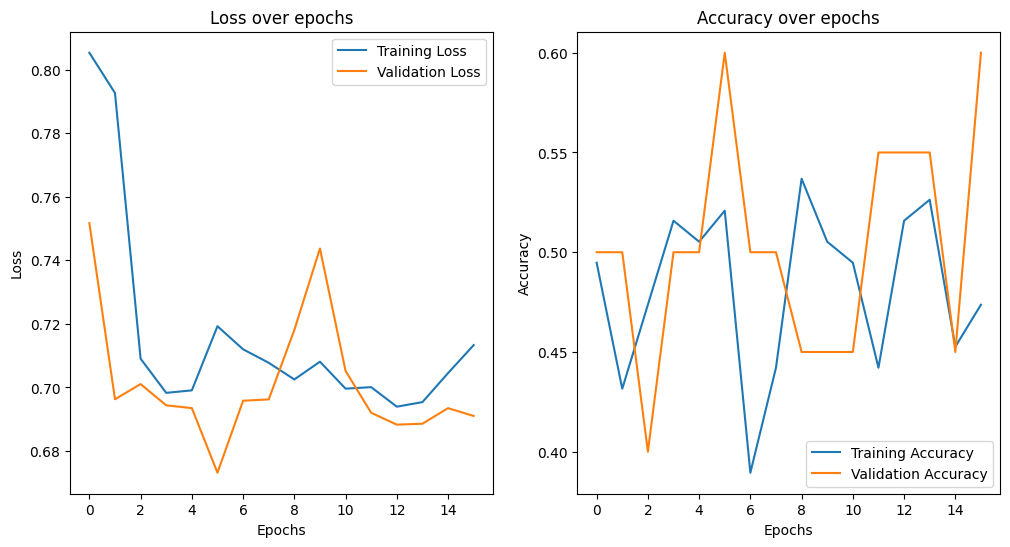

6/6 [==============================] - 3s 245ms/step
Weighted Precision: 0.2287334593572779
Weighted Recall: 0.4782608695652174
Weighted F1 Score: 0.309462915601023
Micro Precision: 0.4782608695652174
Micro Recall: 0.4782608695652174
Micro F1 Score: 0.4782608695652174
Macro Precision: 0.2391304347826087
Macro Recall: 0.5
Macro F1 Score: 0.3235294117647059
Precision (None): [0.47826087 0.        ]
Recall (None): [1. 0.]
F1 Score (None): [0.64705882 0.        ]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, precision_recall_fscore_support
import json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Model oluşturma fonksiyonu
def create_model(dropout_rate=0.5, activation='relu', learning_rate=0.001):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation)(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2, 0.5]
learning_rates = [0.001, 0.01]
epochs = 50  # Başlangıç için daha az epoch

best_accuracy = 0
best_params = {}
all_results = []

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_results_EfficientNetB0.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(dropout_rate=dropout_rate, activation=activation, learning_rate=learning_rate)

                # Define callbacks
                early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
                model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping, model_checkpoint],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                num_epochs = len(history.history['loss'])  # Number of epochs trained
                result = {
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history,
                    'num_epochs': num_epochs  # Add number of epochs to result
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

            except Exception as e:
                print(f"Error with activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved parameters
best_activation = best_params['activation']
best_dropout_rate = best_params['dropout_rate']
best_learning_rate = best_params['learning_rate']

best_model = create_model(dropout_rate=best_dropout_rate, activation=best_activation, learning_rate=best_learning_rate)

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
